# **1. Cost/Loss Functions**

---

## 📌 What are Cost/Loss Functions?

A **cost function** (or **loss function**) is a mathematical formula that **measures the difference between the predicted output of a model and the actual output** (ground truth).

> 👉 In short: It tells the model **how wrong** it is.

The **goal of training** is to **minimize** this cost using optimization algorithms like **Gradient Descent**.

---

## 🔁 Loss vs. Cost

| Term              | Meaning                                  |
| ----------------- | ---------------------------------------- |
| **Loss Function** | Error for a **single** training example  |
| **Cost Function** | Average loss over the **entire dataset** |

---

## 🧮 Formula (General Form)

For a dataset with $n$ samples:

$$
J(\theta) = \frac{1}{n} \sum_{i=1}^{n} \mathcal{L}(y_i, \hat{y}_i)
$$

Where:

* $\theta$: model parameters
* $y_i$: actual value
* $\hat{y}_i$: predicted value
* $\mathcal{L}$: loss function
* $J(\theta)$: cost function

---

## 💡 Why is it important?

* Guides the **training** process
* Helps choose better **model parameters**
* Core component of **backpropagation** in neural networks

---

## 🔍 Types of Loss/Cost Functions

### 1. **Mean Squared Error (MSE)** – Regression

$$
\mathcal{L}(y, \hat{y}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

* Penalizes **larger errors** more than smaller ones
* Smooth and differentiable
* Used in: **Linear Regression**, **Autoencoders**

---

### 2. **Mean Absolute Error (MAE)** – Regression

$$
\mathcal{L}(y, \hat{y}) = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

* Robust to **outliers**
* Not differentiable at 0 (but okay with subgradients)

---

### 3. **Huber Loss** – Combines MSE and MAE

$$
\mathcal{L}_\delta =
\begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{for } |y - \hat{y}| \leq \delta \\
\delta (|y - \hat{y}| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}
$$

* Used in **robust regression**

---

### 4. **Cross-Entropy Loss** – Classification

#### For binary classification:

$$
\mathcal{L}(y, \hat{y}) = -[y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y})]
$$

* Used in: **Logistic Regression**, **Neural Networks**
* Penalizes confident wrong predictions



---

### 5. **Categorical Cross-Entropy** – Multi-class classification

$$
\mathcal{L} = -\sum_{i=1}^{C} y_i \cdot \log(\hat{y}_i)
$$

Where:

* $C$: number of classes
* $y_i$: true one-hot label
* $\hat{y}_i$: predicted probability for class $i$

---

### 6. **KL Divergence** – Difference between two probability distributions

$$
D_{KL}(P || Q) = \sum P(x) \log \frac{P(x)}{Q(x)}
$$

* Used in: **Variational Autoencoders**, **Language Models**

---

### 7. **Hinge Loss** – SVM

$$
\mathcal{L}(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})
$$

* Used for: **Support Vector Machines**
* Only penalizes predictions that are on the wrong side of the margin

---

## ⚙️ Choosing the Right Loss Function

| Problem Type               | Best Loss Function                  |
| -------------------------- | ----------------------------------- |
| Regression (few outliers)  | MSE                                 |
| Regression (with outliers) | MAE or Huber                        |
| Binary Classification      | Binary Cross-Entropy                |
| Multi-Class Classification | Categorical Cross-Entropy           |
| Imbalanced Classification  | Weighted Cross-Entropy / Focal Loss |
| Probabilistic models       | KL Divergence                       |

---

## 🔧 Python Example

```python
import numpy as np
from sklearn.metrics import mean_squared_error, log_loss

# Example values
y_true = np.array([0, 1, 1, 0])
y_pred = np.array([0.1, 0.9, 0.8, 0.2])

# MSE
mse = mean_squared_error(y_true, y_pred)
print(f"MSE: {mse}")

# Binary Cross Entropy
bce = log_loss(y_true, y_pred)
print(f"Binary Cross-Entropy: {bce}")
```

---
## ✅ Summary

* Cost/Loss functions measure **how wrong your model is**
* They're **crucial** for training and backpropagation
* You choose based on your **task type** (regression, classification, etc.)
* You minimize them using **Gradient Descent**

---
---
---


# **2. Convex Functions**

---

## ✅ What is a Convex Function?

A **convex function** is a function where the **line segment between any two points on the graph lies above or on the graph**.

### 🔍 Formal Definition:

A function $f: \mathbb{R}^n \to \mathbb{R}$ is **convex** if for all $x_1, x_2 \in \text{dom}(f)$, and $\lambda \in [0, 1]$:

$$
f(\lambda x_1 + (1 - \lambda)x_2) \leq \lambda f(x_1) + (1 - \lambda)f(x_2)
$$

---

## 📈 Visualization

Imagine a **U-shaped** curve — that’s convex. If you draw a line between any two points on the curve, that line will lie **above** the curve.

---

## 🧠 Why are Convex Functions Important in AI?

* **Loss functions** like MSE, logistic loss, and cross-entropy are convex (or close to it).
* Convexity ensures that **any local minimum is also a global minimum**.
* Easier to optimize using algorithms like **Gradient Descent**.

---

## 🧮 Examples of Convex Functions

| Function         | Convexity                 |   |        |
| ---------------- | ------------------------- | - | ------ |
| $f(x) = x^2$     | Convex                    |   |        |
| $f(x) = e^x$     | Convex                    |   |        |
| $f(x) = \log(x)$ | **Concave**, not convex   |   |        |
| ( f(x) =         | x                         | ) | Convex |
| $f(x) = -x^2$    | Not convex (it's concave) |   |        |

---

## 🔁 Convex vs Non-Convex

| Feature      | Convex              | Non-Convex                      |
| ------------ | ------------------- | ------------------------------- |
| Minima       | Global minimum only | Can have multiple local minima  |
| Optimization | Easier              | Harder, may require heuristics  |
| Example      | $x^2$, $e^x$        | Sinusoidal functions, deep nets |

---

## 🧩 Properties of Convex Functions

1. **Second Derivative Test**:

   * If $f''(x) \geq 0$, function is convex
   * If $f''(x) > 0$, it's **strictly convex**

2. **First-order Condition** (Gradient):
   For differentiable functions, convexity also implies:

   $$
   f(y) \geq f(x) + \nabla f(x)^T (y - x)
   $$

3. **Jensen's Inequality**:
   Important property used in proving the convexity of expectations.

---

## 🧠 Role in Machine Learning

* **Convex Optimization**: Guarantees **efficient convergence** during training
* **Regularization** (L2 norm is convex)
* **SVMs**, **Logistic Regression**, **Ridge Regression** all use convex loss functions
* Deep Learning uses **non-convex** functions, but we apply **convex approximations** during optimization

---

## ✨ Summary

* Convex functions are foundational in AI for reliable optimization
* If a loss function is convex → optimization is easier and globally optimal
* You can test convexity using 1st and 2nd derivatives
* Many ML algorithms are **based on convex loss functions**

---
---
---

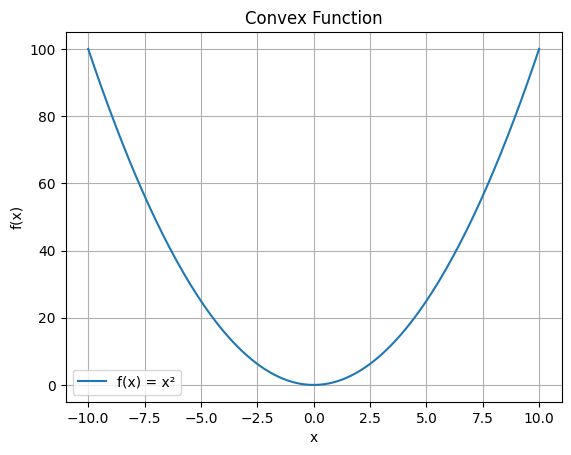

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)
y = x**2  # Convex function

plt.plot(x, y, label='f(x) = x²')
plt.title("Convex Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# **3. Gradient Descent (Batch, Stochastic, Mini-Batch)**

---

## ✅ What is Gradient Descent?

Gradient Descent is an **optimization algorithm** used to minimize a **loss (cost) function** by updating parameters (weights) in the direction of the **negative gradient**.

> Imagine standing on a mountain and taking steps downhill — gradient descent is how AI models "learn" by moving downhill on a cost surface.

---

## 🔍 Mathematical Formulation

For a function $f(\theta)$, update rule:

$$
\theta := \theta - \eta \cdot \nabla f(\theta)
$$

Where:

* $\theta$: model parameters
* $\eta$: learning rate
* $\nabla f(\theta)$: gradient (partial derivatives) of loss function w\.r.t. parameters

---

## 🧠 Why is it Important in AI?

* Used in **Linear Regression**, **Logistic Regression**, **Neural Networks**
* Core of **backpropagation**
* Makes models **learn from data by reducing errors**

---

## 🧩 Types of Gradient Descent

### 1. **Batch Gradient Descent**

* **Uses all training data** to compute the gradient
* More stable, but slow for large datasets

**Update Rule**:

$$
\theta := \theta - \eta \cdot \frac{1}{n} \sum_{i=1}^{n} \nabla_{\theta} L(x_i, y_i)
$$

**Pros**:

* Converges smoothly
* Good for small datasets

**Cons**:

* Memory heavy
* Slow for large datasets

---

### 2. **Stochastic Gradient Descent (SGD)**

* **Uses one data point** at a time
* Faster updates, but more noisy

**Update Rule**:

$$
\theta := \theta - \eta \cdot \nabla_{\theta} L(x_i, y_i)
$$

**Pros**:

* Faster for large datasets
* Often escapes local minima due to randomness

**Cons**:

* High variance in updates
* Convergence is noisy

---

### 3. **Mini-Batch Gradient Descent** (Most Used in DL)

* Combines both approaches
* Uses a **subset (mini-batch)** of data (e.g., 32, 64, 128 samples)

**Pros**:

* Balanced speed and stability
* Efficient use of hardware (GPUs)

---

## ⚙️ Visual Intuition

🧠 Gradient = slope
🔻 You take steps opposite to slope
📉 Each step = a learning iteration to minimize error

![Gradient Descent GIF](https://miro.medium.com/v2/resize\:fit:600/format\:webp/1*FwjrPEx8GrnO3kKfgNqLhQ.gif)

---

## 🧠 Advanced Note

* For Deep Learning, SGD is usually used with **momentum**, **Adam**, **RMSprop**
* Gradient Descent doesn’t guarantee reaching **global minima** in **non-convex** functions (like neural nets)

---

## ✨ Summary

| Type       | Stability | Speed | Use-case         |
| ---------- | --------- | ----- | ---------------- |
| Batch      | High      | Slow  | Small datasets   |
| SGD        | Low       | Fast  | Online/streaming |
| Mini-Batch | Medium    | Fast  | Deep Learning    |

---
---
---

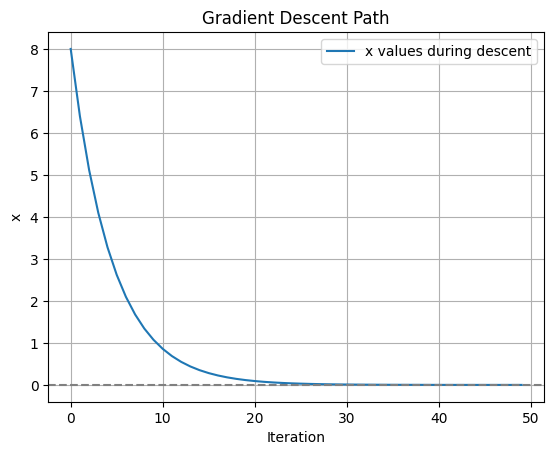

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define function and derivative
def f(x): return x**2 + 5
def df(x): return 2*x

# Initialize
x = 10
learning_rate = 0.1
epochs = 50
x_vals = []

for i in range(epochs):
    grad = df(x)
    x = x - learning_rate * grad
    x_vals.append(x)

plt.plot(x_vals, label='x values during descent')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Gradient Descent Path")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.legend()
plt.grid()
plt.show()

# **4. Convergence & Learning Rate in Gradient Descent**
---

## 📌 What is **Convergence**?

**Convergence** refers to the point during training when the **loss (cost) function stops decreasing significantly**, indicating the model has **learned as much as it can** from the data.

### 🔁 You reach convergence when:

* The model's parameters (weights) **stabilize**
* Loss reduction per epoch becomes **negligible**
* Model stops improving on validation data (avoid overfitting)

---

## 🧠 Why is Convergence Important?

* Ensures the model is **well-trained**
* Helps avoid **over-training** or **under-training**
* Indicates when to **stop training** (early stopping)

---

## 🧮 What is Learning Rate (η)?

The **learning rate** controls how big each step is in the direction of the negative gradient.

$$
\theta := \theta - \eta \cdot \nabla J(\theta)
$$

Where:

* $\theta$: model parameters
* $\eta$: **learning rate**
* $\nabla J(\theta)$: gradient of the cost function

---

## ⚖️ How Learning Rate Affects Convergence

| Learning Rate                | Result                                          |
| ---------------------------- | ----------------------------------------------- |
| **Too Small** ($\eta \ll 1$) | Slow convergence, may get stuck in local minima |
| **Too Large** ($\eta \gg 1$) | May overshoot or never converge (oscillate)     |
| **Just Right**               | Smooth, stable descent to global/local minimum  |

---

### 📊 Visualization

![Learning Rate Visual](https://upload.wikimedia.org/wikipedia/commons/7/76/Stochastic_gradient_descent_animation.gif)

* **Left**: Too small – slow convergence
* **Middle**: Optimal
* **Right**: Too large – bouncing and divergence

---

## 🎯 Convergence Criteria

We usually check for convergence by:

1. **Loss Threshold**:

   $$
   |J(\theta_{t+1}) - J(\theta_t)| < \epsilon
   $$

2. **Gradient Norm**:

   $$
   ||\nabla J(\theta)|| < \delta
   $$

3. **Max Iterations**: Hard limit (e.g., 1000 iterations)

---

## 🧪 Adaptive Learning Rate Techniques

In practice, **adaptive optimizers** help find a better learning rate:

* **Adam** (Adaptive Moment Estimation)
* **RMSProp**
* **AdaGrad**
* **Learning Rate Schedulers** (e.g., step decay, exponential decay)

---

## 🧑‍💻 Practical Tip

Use **learning rate schedulers** in frameworks like TensorFlow or PyTorch:

```python
from torch.optim.lr_scheduler import StepLR

scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
```

---

## ✅ Summary

| Concept               | Description                            |
| --------------------- | -------------------------------------- |
| **Convergence**       | When cost stops changing significantly |
| **Learning Rate (η)** | Controls step size                     |
| **Too Small η**       | Slow learning                          |
| **Too Big η**         | Diverges                               |
| **Optimal η**         | Fast, stable convergence               |
| **Adaptive methods**  | Adjust η dynamically (Adam, RMSProp)   |

---
---
---